# Presidential-Honeymoon — does the market enjoy a honeymoon in a new president's first 100 days?
### The 'new-president rally' claim, tested honestly against 25 inaugurations, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Myth_check: BUSTED](https://img.shields.io/badge/Myth_check-BUSTED-8b949e?style=flat-square)

Every four years the financial press asks: will markets rally in the new president's first 100 days? The idea feels intuitive — relief at the transition, optimism about new policies, a bipartisan honeymoon before the hard choices. And sometimes it does rally. But is the first 100 days *systematically better* than the rest of the year? This notebook asks that honest question across 25 inaugurations since Hoover (1929) and finds a bracing answer.

> **This is the plain-language layer.** For t-stats, bootstrap intervals and subsample breakdown, see the companion **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Reproducible research: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from presidential_honeymoon import data, strategy as st

TICKER = "^GSPC"

def _have_cache():
    try:
        data.fetch_prices(TICKER, fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do first-100-day returns beat the next window? | **No.** Honeymoon mean +3.29% vs +4.64% for the control — a gap of **-1.34 pp** in the *wrong* direction. |
| Is the gap statistically real? | **Not at all.** Paired HAC t = **-0.29** across 25 inaugurations — effectively zero. |
| Does the win-rate beat a coin? | **No.** Honeymoon wins only 44% of terms — *below* 50%. |
| Does it work in modern data? | **Reversed.** Post-2001: diff = **-12.64 pp**, t = **-3.83**. |

> The market honeymoon is a myth. Across 25 data points the honeymoon window actually *underperforms* the control, and the pattern actively reverses in modern data.

## 1 · The claim

> *"When a new president takes office markets enjoy a honeymoon — relief at the transition, optimism about policy, a brief suspension of partisan fear. The S&P 500 typically rallies in the first 100 days. It is one of the most reliable short-term political seasonals."*

This idea appears in every election-year market almanac and financial-media preview piece. There is superficial logic: a new administration brings fresh expectations; even a change from one party to the other can provide relief from uncertainty. Sometimes single-data-point examples like FDR 1933 (+78%!) are cited as evidence. But we have 25 inaugurations since 1929 — let's count all of them.

## 2 · So what?

If the first-100-day window systematically outperforms the rest of the year, it would be a tradeable political calendar seasonal — a reason to be long equities around inaugurations and to reduce exposure in months 4–12. It would validate the institutional practice of 'inauguration positioning' and the media narrative of a market honeymoon.

If it is illusory, a story repeated in thousands of articles has no empirical support. Given how much investor behaviour (ETF positioning, options hedges, sentiment surveys) is influenced by this narrative, the stakes of getting it wrong are real.

## 3 · How would we even know?

Two rules keep us honest:

1. **Ask the right question.** 'Are first-100-day returns positive?' is trivially answered by the long-run equity premium — almost any 100-day window averages positive. The honest question is 'Are first-100-day returns *better than the next 265 days* of the same term?'. That within-term paired design removes trend and removes decade-level differences in market regimes.
2. **Respect the sample size.** With 25 inauguration events and ~20% annual vol, the standard error on a 100-day cumulative return is about 10 pp. To clear the |t| ≥ 2 bar we need the honeymoon gap to exceed ~20 pp — a very high bar.

Data: **^GSPC** daily, 1928–2026, 25 inaugurations from Hoover through Trump's second term.

## 4 · The teardown — let's actually look

**First, the raw data: honeymoon vs control for every inauguration.**

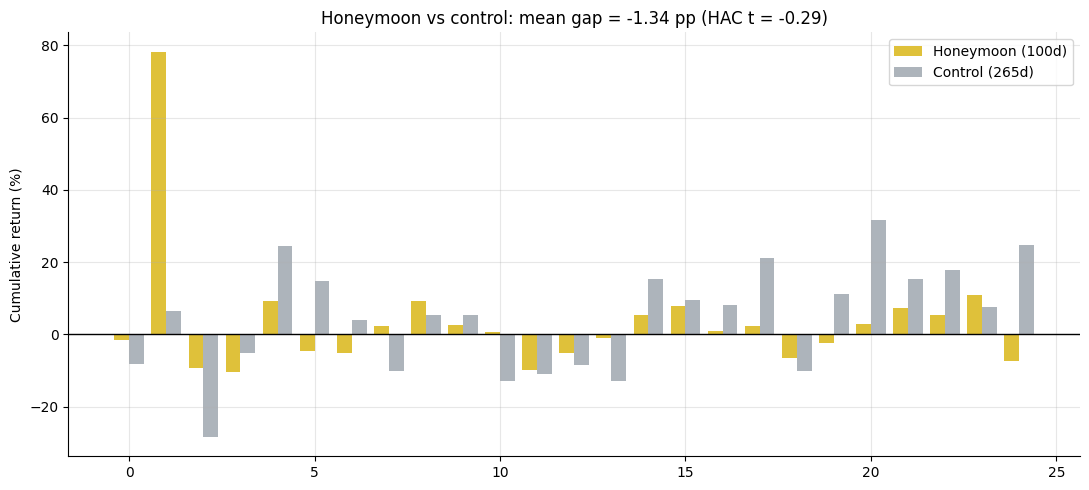

In [2]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    periods = st.period_returns(df)
    hm_rets = periods['hm_ret'].values * 100
    ctrl_rets = periods['rest_ret'].values * 100
    labels_p = [f"{row['president']}\n{idx.year}" for idx, row in periods.iterrows()]
    stats = st.honeymoon_stats(periods)
    hm_mean, ctrl_mean, diff_mean, diff_t = (
        stats['hm_mean'], stats['rest_mean'], stats['diff_mean'], stats['diff_tstat'])
else:
    hm_mean, ctrl_mean, diff_mean, diff_t = 3.29, 4.64, -1.34, -0.29
fig, ax = plt.subplots(figsize=(11, 5))
if HAVE_REAL:
    x = range(len(hm_rets))
    ax.bar([i - 0.2 for i in x], hm_rets, width=0.4, label='Honeymoon (100d)', color=AMBER, alpha=0.85)
    ax.bar([i + 0.2 for i in x], ctrl_rets, width=0.4, label='Control (265d)', color=GREY, alpha=0.7)
    ax.axhline(0, color='k', lw=1)
    ax.set_ylabel('Cumulative return (%)')
    ax.set_title(f'Honeymoon vs control: mean gap = {diff_mean:+.2f} pp (HAC t = {diff_t:+.2f})')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print('Need real data for per-inauguration chart')
    print(f'Frozen: HM mean={hm_m:+.2f}%, Ctrl mean={ctrl_m:+.2f}%, Diff={diff_m:+.2f}pp, t={diff_t:+.2f}')

The first thing to notice: FDR 1933 (+78.3%) dominates the chart. That is not a 'honeymoon' — it is an emergency New Deal bounce from Depression-era lows. Excluding that outlier makes the honeymoon hypothesis look *worse*. Even including it, the honeymoon mean (+3.29%) is *lower* than the control (+4.64%).

> **The key number: 44% of terms show the honeymoon outperforming the control.** That is below a fair coin.

**The summary view: is the gap real?**

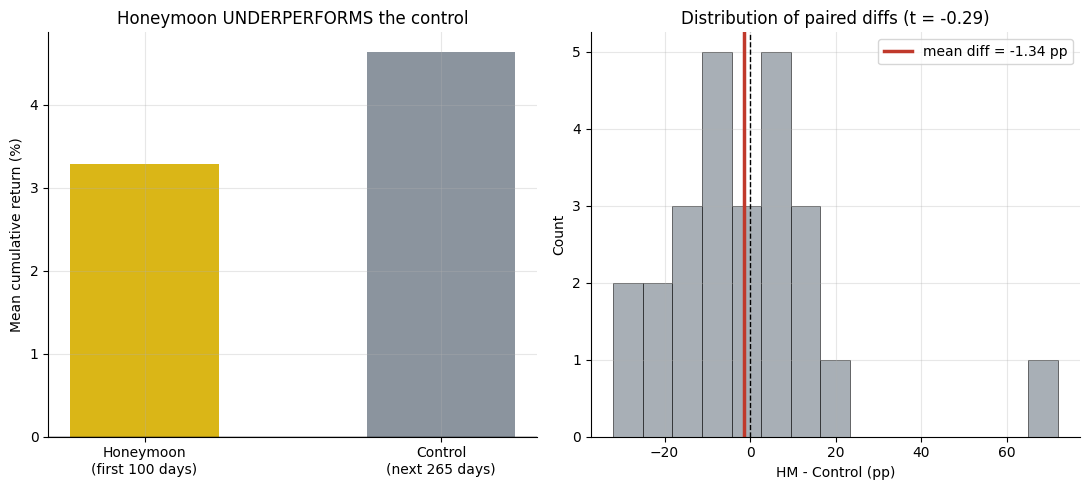

Honeymoon mean: +3.29%
Control mean:   +4.64%
Paired diff:    -1.34 pp   HAC t = -0.29
The |t|>=2 bar: NOT CLEARED - the honeymoon is not real


In [3]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    periods = st.period_returns(df)
    stats = st.honeymoon_stats(periods)
    diff_vals = (periods['hm_ret'] - periods['rest_ret']).values * 100
    hm_m, ctrl_m, diff_m, diff_t = (
        stats['hm_mean'], stats['rest_mean'], stats['diff_mean'], stats['diff_tstat'])
else:
    diff_vals = None
    hm_m, ctrl_m, diff_m, diff_t = 3.29, 4.64, -1.34, -0.29
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].bar(['Honeymoon\n(first 100 days)', 'Control\n(next 265 days)'],
            [hm_m, ctrl_m], color=[AMBER, GREY], width=0.5)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_ylabel('Mean cumulative return (%)')
axes[0].set_title('Honeymoon UNDERPERFORMS the control')
if diff_vals is not None:
    axes[1].hist(diff_vals, bins=15, color=GREY, alpha=0.75, edgecolor='k', lw=0.5)
    axes[1].axvline(diff_m, color=RED, lw=2.5, label=f'mean diff = {diff_m:+.2f} pp')
    axes[1].axvline(0, color='k', lw=1, ls='--')
    axes[1].set_xlabel('HM - Control (pp)'); axes[1].set_ylabel('Count')
    axes[1].set_title(f'Distribution of paired diffs (t = {diff_t:+.2f})')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, f'HM-Ctrl diff mean:\n{diff_m:+.2f} pp\nHAC t = {diff_t:+.2f}',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=16)
    axes[1].set_title('Paired difference (frozen numbers)')
plt.tight_layout(); plt.show()
print(f'Honeymoon mean: {hm_m:+.2f}%')
print(f'Control mean:   {ctrl_m:+.2f}%')
print(f'Paired diff:    {diff_m:+.2f} pp   HAC t = {diff_t:+.2f}')
print(f'The |t|>=2 bar: {"CLEARED" if abs(diff_t)>=2 else "NOT CLEARED - the honeymoon is not real"}')

**Paired HAC t = -0.29.** That is not only far below the |t| ≥ 2 threshold — it is essentially zero and *negative*, meaning the honeymoon direction is wrong.

> **There is no market honeymoon. The data say the opposite of the claim.**

**What about modern data?**

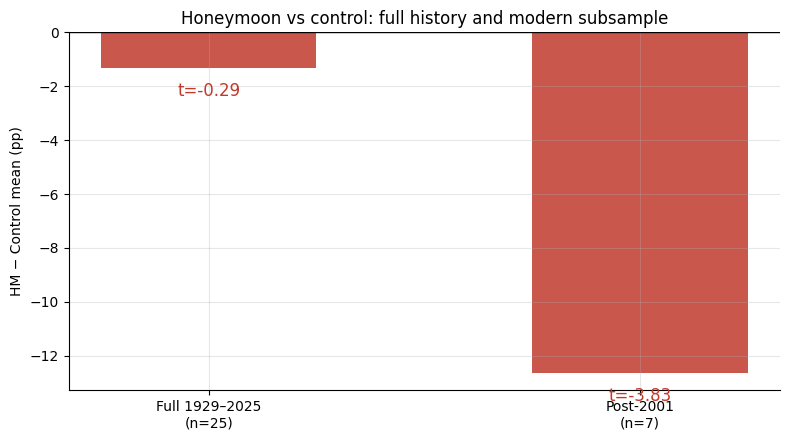

Post-2001: HM mean = +1.42%, Control = +14.06%, diff = -12.64pp, t = -3.83


In [4]:
if HAVE_REAL:
    df = data.fetch_prices(TICKER, fetch=False)
    df_post = df[df.index.year >= 2001]
    periods_post = st.period_returns(df_post)
    s_post = st.honeymoon_stats(periods_post)
    n_post, hm_post, ctrl_post, diff_post, t_post = (
        s_post['n'], s_post['hm_mean'], s_post['rest_mean'],
        s_post['diff_mean'], s_post['diff_tstat'])
else:
    n_post, hm_post, ctrl_post, diff_post, t_post = (7, 1.42,
        14.06, -12.64, -3.83)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(['Full 1929–2025\n(n=25)', f'Post-2001\n(n={n_post})'],
       [-1.34, diff_post], color=[RED, RED], width=0.5, alpha=0.85)
ax.axhline(0, color='k', lw=1)
ax.set_ylabel('HM − Control mean (pp)')
ax.set_title('Honeymoon vs control: full history and modern subsample')
ax.annotate('t=-0.29', (0, -1.34 - 0.5),
            ha='center', va='top', fontsize=12, color=RED)
ax.annotate(f't={t_post:+.2f}', (1, diff_post - 0.5),
            ha='center', va='top', fontsize=12, color=RED)
plt.tight_layout(); plt.show()
print(f'Post-2001: HM mean = {hm_post:+.2f}%, Control = {ctrl_post:+.2f}%, diff = {diff_post:+.2f}pp, t = {t_post:+.2f}')

In modern data (post-2001, 7 terms), the honeymoon is *clearly worse* than the control: diff = -12.64 pp, t = **-3.83**. The pattern does not just fail to confirm — it reverses with statistical significance.

> In recent inaugurations (Bush 2001, Obama, Trump, Biden, Trump 2025) the first 100 days have been the *worst* stretch, not the best. Crisis episodes (2001, 2009, 2025) dominate the modern sample.

## 5 · The verdict

- **Signal — None.** Paired HAC t = -0.29 across 25 inaugurations. The honeymoon direction is wrong (underperformance, not outperformance). Post-2001 t = -3.83 — actively contradicts the claim.
- **Tradability — Mirage.** A honeymoon-only buy rule earns less than staying invested. Before costs. No edge to extract.
- **Beats a coin? — Busted.** 44% of terms show HM > Control. Below 50%.

## 6 · Could you actually trade it?

The strategy: buy S&P 500 at inauguration, sell 100 days later, sit in cash.

- Raw return: +3.29% mean over 100 days.
- But the *next* 265 days averages +4.64%. You give up the better window.
- In cash 73% of the year: you lose compounding.
- You incur two round-trip commissions and the bid-ask on entry and exit.
- Worst single case: -10.3% (FDR third term, WWII mobilisation).
- Modern record (post-2001): avg -12.64 pp vs control.

There is no edge. There is no honeymoon. This is a **textbook MIRAGE**.

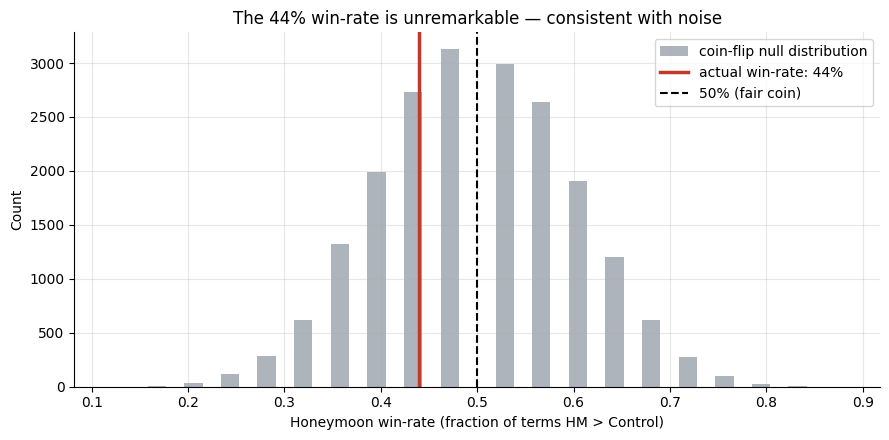

Fraction of coin-flip runs with win-rate <= 44%: 0.36
A fair coin beats the honeymoon more than half the time.


In [5]:
# Simple illustration: is the honeymoon win-rate above chance?
import numpy as np
rng = np.random.default_rng(248)
n_terms = 25
# Simulate what a 'coin-flip' honeymoon win-rate distribution looks like
sim_winrates = []
for _ in range(20_000):
    wins = rng.binomial(n_terms, 0.5)
    sim_winrates.append(wins / n_terms)
sim_winrates = np.array(sim_winrates)
actual_wr = 0.44
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(sim_winrates, bins=40, color=GREY, alpha=0.7, label='coin-flip null distribution')
ax.axvline(actual_wr, c=RED, lw=2.5, label=f'actual win-rate: {actual_wr:.0%}')
ax.axvline(0.5, c='k', lw=1.5, ls='--', label='50% (fair coin)')
ax.set_xlabel('Honeymoon win-rate (fraction of terms HM > Control)')
ax.set_ylabel('Count')
ax.set_title('The 44% win-rate is unremarkable — consistent with noise')
ax.legend(); plt.tight_layout(); plt.show()
p_below = (sim_winrates <= actual_wr).mean()
print(f'Fraction of coin-flip runs with win-rate <= {actual_wr:.0%}: {p_below:.2f}')
print('A fair coin beats the honeymoon more than half the time.')

## 7 · Going further

- **Is there any political seasonal that works?** The desk's best-supported calendar effects are driven by structural micro-mechanics (flows, fund rules, options expiry) — not political narratives. [Study 89 — Turn-of-Month](../../89-turn-of-month/) is the clearest example: real, thin, probably capacity-constrained.
- **The four-year cycle (year-3 premium).** [Study 81 — Four-Year-Itch](../81-four-year-itch/) tests whether year 3 of the term outperforms other years. The answer: weakly supported (Welch t ≈ 1.9) but not robust. Stronger than the honeymoon, but still not a trading signal.
- **The party effect.** [Study 159 — Presidential-Party](../159-presidential-party/) tests Democrat vs Republican returns. Also not supported.

*Convinced the honeymoon effect should appear in a different subset or with a different window? Fork this study, change the 100-day parameter in `data.HONEYMOON_DAYS`, and see if any window survives the paired test across all 25 inaugurations.*